This colab creates 3 different datasets:

**balanced_df** = using every single song per decade, downsampled randomly until 20% hit rate

**balanced_df_2000** = downsampled randomly but until there's only 2000 songs and also 20% hit rate

**balanced_1700_unPOP_df** = downsampled by only keeping the non-hits that have a 0 of popularity spotify score but until there's only 1700 songs and also 20% hit rate. 1700 was chosen because there weren't enough songs in the 60s.

In [ ]:
!pip install opendatasets -q

import opendatasets as od
od.download('https://www.kaggle.com/datasets/serkantysz/550k-spotify-songs-audio-lyrics-and-genres?select=songs.csv')
od.download('https://www.kaggle.com/datasets/dhruvildave/billboard-the-hot-100-songs')

Skipping, found downloaded files in "./550k-spotify-songs-audio-lyrics-and-genres" (use force=True to force download)
Skipping, found downloaded files in "./billboard-the-hot-100-songs" (use force=True to force download)


In [ ]:
import pandas as pd
import re

songs_df   = pd.read_csv('/content/550k-spotify-songs-audio-lyrics-and-genres/songs.csv')
charts_df  = pd.read_csv('/content/billboard-the-hot-100-songs/charts.csv')

# showing all features in the dataset
print('songs_df columns:', songs_df.columns.tolist())
print('songs_df shape:  ', songs_df.shape)

songs_df columns: ['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres']
songs_df shape:   (550622, 24)


In [ ]:
# printing # of songs per decade
songs_df['decade'] = (songs_df['year'] // 10 * 10).astype(str) + 's'
print(songs_df.groupby('decade').size().to_string())

decade
1900s        30
1910s         3
1920s       156
1930s       288
1940s       437
1950s      4119
1960s     11344
1970s     17570
1980s     20729
1990s     42913
2000s    162161
2010s    225362
2020s     65510


In [ ]:
import ast

def normalize_text(text):
    if pd.isna(text): return ''
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

# keeping first artist
def clean_artist_name(artist):
    for sep in [' featuring ', ' feat. ', ' feat ', ' ft. ', ' ft ', ' x ', ' & ', ' with ']:
        artist = artist.lower().split(sep)[0]
    return artist.strip()

# keeping first artist
def get_primary_artist(artists_str):
    try:
        artists_list = ast.literal_eval(artists_str)
        return normalize_text(artists_list[0])
    except:
        return clean_artist_name(normalize_text(str(artists_str)))

#setting normalized song titles and artist names
songs_df['song_normalized']   = songs_df['name'].apply(normalize_text)
songs_df['artist_normalized'] = songs_df['artists'].apply(get_primary_artist)

charts_df['song_normalized']   = charts_df['song'].apply(normalize_text)
charts_df['artist_normalized'] = charts_df['artist'].apply(lambda x: clean_artist_name(normalize_text(x)))

In [ ]:
# creating the is_hit label feature to songs dataframe
top10 = charts_df[charts_df['rank'] <= 10][['song_normalized', 'artist_normalized']].drop_duplicates()
top10['is_hit'] = 1

songs_df = songs_df.merge(top10, on=['song_normalized', 'artist_normalized'], how='left')
songs_df['is_hit'] = songs_df['is_hit'].fillna(0).astype(int)

print(f"Total songs:  {len(songs_df):,}")
print(f"Hits (top10): {songs_df['is_hit'].sum():,}")
print(f"Overall hit rate: {songs_df['is_hit'].mean():.1%}")

Total songs:  550,622
Hits (top10): 7,292
Overall hit rate: 1.3%


In [ ]:
# checking number of hits per decade
decade_stats = songs_df.groupby('decade')['is_hit'].agg(
    total='count',
    hits='sum'
)
decade_stats['hit_rate'] = (decade_stats['hits'] / decade_stats['total']).map('{:.1%}'.format)
print(decade_stats[decade_stats.index >= '1960s'].to_string())

         total  hits hit_rate
decade                       
1960s    11344   437     3.9%
1970s    17570   604     3.4%
1980s    20729   796     3.8%
1990s    42913   850     2.0%
2000s   162161  1821     1.1%
2010s   225362  2128     0.9%
2020s    65510   620     0.9%


In [ ]:
print(songs_df.columns.tolist())
songs_df_unPop = songs_df[~((songs_df['popularity'] > 0) & (songs_df['is_hit'] == 0))]

['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres', 'decade', 'song_normalized', 'artist_normalized', 'is_hit']


In [ ]:
# checking how many hits there are per decade after taking out non-zero non_hit songs
decade_stats = songs_df_unPop.groupby('decade')['is_hit'].agg(
    total='count',
    hits='sum'
)
decade_stats['hit_rate'] = (decade_stats['hits'] / decade_stats['total']).map('{:.1%}'.format)
print(decade_stats[decade_stats.index >= '1960s'].to_string())

        total  hits hit_rate
decade                      
1960s    1798   437    24.3%
1970s    3496   604    17.3%
1980s    4212   796    18.9%
1990s   10536   850     8.1%
2000s   43777  1821     4.2%
2010s   70817  2128     3.0%
2020s   18636   620     3.3%


In [ ]:
# @title Downsample 1700 - downsample only with 0 popularity songs for non-hits
# downsampling to 20% hit rate, at only 2000 songs
balanced_2000_decades = []

for decade, group in songs_df_unPop.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_hits = 340
    target_non_hits = 340 * 4
    hits_sampled = hits.sample(n=target_hits, random_state=42)
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced_2000 = pd.concat([hits_sampled, non_hits_sampled])
    balanced_2000_decades.append(balanced_2000)
    print(f"{decade}: {len(hits_sampled)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits_sampled)/len(balanced_2000):.1%}")

balanced_1700_unPOP_df = pd.concat(balanced_2000_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_1700_unPOP_df):,} songs")

1960s: 340 hits, 1360 non-hits, hit rate: 20.0%
1970s: 340 hits, 1360 non-hits, hit rate: 20.0%
1980s: 340 hits, 1360 non-hits, hit rate: 20.0%
1990s: 340 hits, 1360 non-hits, hit rate: 20.0%
2000s: 340 hits, 1360 non-hits, hit rate: 20.0%
2010s: 340 hits, 1360 non-hits, hit rate: 20.0%
2020s: 340 hits, 1360 non-hits, hit rate: 20.0%

Total: 11,900 songs


In [ ]:
# @title Downsample 2000 - random Downsample
# downsampling to 20% hit rate, at only 2000 songs
balanced_2000_decades = []

for decade, group in songs_df.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_hits = 400
    target_non_hits = 400 * 4
    hits_sampled = hits.sample(n=target_hits, random_state=42)
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced_2000 = pd.concat([hits_sampled, non_hits_sampled])
    balanced_2000_decades.append(balanced_2000)
    print(f"{decade}: {len(hits_sampled)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits_sampled)/len(balanced_2000):.1%}")

balanced_2000_df = pd.concat(balanced_2000_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_2000_df):,} songs")

1960s: 400 hits, 1600 non-hits, hit rate: 20.0%
1970s: 400 hits, 1600 non-hits, hit rate: 20.0%
1980s: 400 hits, 1600 non-hits, hit rate: 20.0%
1990s: 400 hits, 1600 non-hits, hit rate: 20.0%
2000s: 400 hits, 1600 non-hits, hit rate: 20.0%
2010s: 400 hits, 1600 non-hits, hit rate: 20.0%
2020s: 400 hits, 1600 non-hits, hit rate: 20.0%

Total: 14,000 songs


In [ ]:
# @title Downsample Full
# downsampling to 20% hit rate
balanced_decades = []

for decade, group in songs_df.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_non_hits = min(len(hits) * 4, len(non_hits))
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced = pd.concat([hits, non_hits_sampled])
    balanced_decades.append(balanced)
    print(f"{decade}: {len(hits)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits)/len(balanced):.1%}")

balanced_df = pd.concat(balanced_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_df):,} songs")

1960s: 437 hits, 1748 non-hits, hit rate: 20.0%
1970s: 604 hits, 2416 non-hits, hit rate: 20.0%
1980s: 796 hits, 3184 non-hits, hit rate: 20.0%
1990s: 850 hits, 3400 non-hits, hit rate: 20.0%
2000s: 1821 hits, 7284 non-hits, hit rate: 20.0%
2010s: 2128 hits, 8512 non-hits, hit rate: 20.0%
2020s: 620 hits, 2480 non-hits, hit rate: 20.0%

Total: 36,280 songs


In [ ]:
print(balanced_2000_df.columns.tolist())

['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres', 'decade', 'song_normalized', 'artist_normalized', 'is_hit']


In [ ]:
balanced_2000_df = balanced_2000_df[['id', 'decade', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit']]
balanced_df = balanced_df[['id', 'decade', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit']]
balanced_1700_unPOP_df = balanced_1700_unPOP_df[['id', 'decade', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit']]

In [ ]:
print(balanced_2000_df.columns.tolist())

['id', 'decade', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit']


TOKENIZATION START

In [ ]:
# install dependencies
!pip install gensim nltk -q

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def tokenize_lyrics(text):
    if pd.isna(text) or text == '':
        return []
    tokens = word_tokenize(text.lower())
    # keep only alphabetic tokens and drop stopwords
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return tokens

balanced_2000_df['tokens'] = balanced_2000_df['lyrics'].apply(tokenize_lyrics)

In [ ]:
from gensim.models import Word2Vec

# train one Word2Vec model per decade
w2v_models = {}

for decade, group in balanced_2000_df.groupby('decade'):
    sentences = [tokens for tokens in group['tokens'] if len(tokens) > 0]
    model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=5,
        min_count=2,       # ignore words appearing < 2 times
        workers=4,
        epochs=10,
        seed=42
    )
    w2v_models[decade] = model

In [ ]:
import numpy as np

def get_doc_vector(tokens, model, vector_size=100):
    """Mean-pool Word2Vec vectors for all known tokens in a song."""
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

# per-decade embedding matrices to be used for later classifiers
decade_embeddings = {}

for decade, group in balanced_2000_df.groupby('decade'):
    model = w2v_models[decade]
    X = np.array([get_doc_vector(row['tokens'], model) for _, row in group.iterrows()])
    y = group['is_hit'].values
    decade_embeddings[decade] = {'X': X, 'y': y, 'index': group.index}



## Per-Decade Classification: KNN & SVM

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

results = []

for decade, data in decade_embeddings.items():
    X, y = data['X'], data['y']

    # skip decades with not enough samples to properly split
    if len(y) < 20:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # importing scaler for distance-based
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    for model_name, clf in [
        ('KNN', KNeighborsClassifier(n_neighbors=5)),
        ('SVM', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)),
    ]:
        clf.fit(X_train_sc, y_train)
        y_pred = clf.predict(X_test_sc)

        results.append({
            'Decade':    decade,
            'Model':     model_name,
            'Accuracy':  accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall':    recall_score(y_test, y_pred, zero_division=0),
            'F1-Score':  f1_score(y_test, y_pred, zero_division=0),
        })

print(f"Training complete - {len(results)} model/decade combinations evaluated.")

Training complete - 14 model/decade combinations evaluated.


## Evaluation Results

In [ ]:
results_df = pd.DataFrame(results).sort_values(['Decade', 'Model']).reset_index(drop=True)

# numeric columns formatted to 4 decimal places
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
display_df = results_df.copy()
display_df[metric_cols] = display_df[metric_cols].applymap(lambda x: f'{x:.4f}')

print('Per-Decade KNN & SVM Evaluation')
print('=' * 62)
print(display_df.to_string(index=False))

Per-Decade KNN & SVM Evaluation
Decade Model Accuracy Precision Recall F1-Score
 1960s   KNN   0.7925    0.4516 0.1750   0.2523
 1960s   SVM   0.8150    0.8750 0.0875   0.1591
 1970s   KNN   0.7900    0.4167 0.1250   0.1923
 1970s   SVM   0.8200    1.0000 0.1000   0.1818
 1980s   KNN   0.7925    0.4444 0.1500   0.2243
 1980s   SVM   0.8175    0.8182 0.1125   0.1978
 1990s   KNN   0.7850    0.4318 0.2375   0.3065
 1990s   SVM   0.8275    0.7200 0.2250   0.3429
 2000s   KNN   0.7950    0.4762 0.2500   0.3279
 2000s   SVM   0.8050    0.5556 0.1250   0.2041
 2010s   KNN   0.8025    0.5102 0.3125   0.3876
 2010s   SVM   0.8375    0.8947 0.2125   0.3434
 2020s   KNN   0.8375    0.7027 0.3250   0.4444
 2020s   SVM   0.8675    0.9655 0.3500   0.5138


/tmp/ipykernel_1464/1723379491.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display_df[metric_cols] = display_df[metric_cols].applymap(lambda x: f'{x:.4f}')


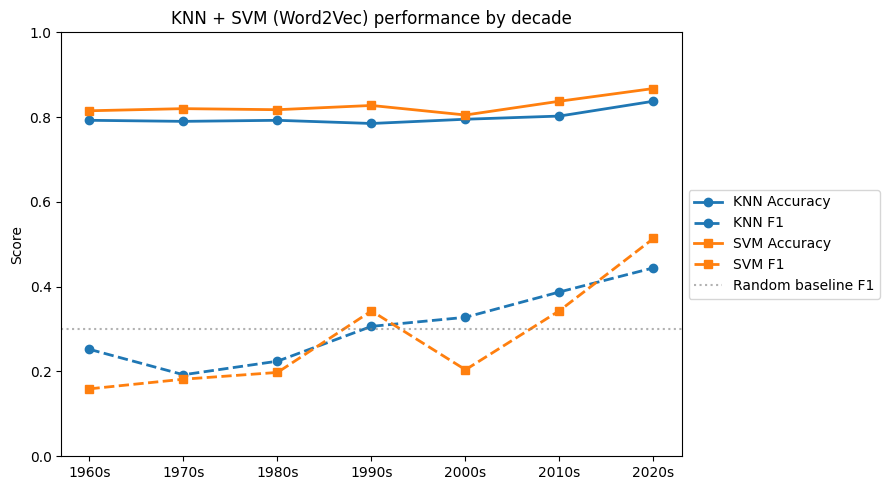

In [ ]:
import matplotlib.pyplot as plt

decades = sorted(results_df['Decade'].unique())
knn_acc = [results_df[(results_df['Decade']==d) & (results_df['Model']=='KNN')]['Accuracy'].values[0] for d in decades]
knn_f1  = [results_df[(results_df['Decade']==d) & (results_df['Model']=='KNN')]['F1-Score'].values[0] for d in decades]
svm_acc = [results_df[(results_df['Decade']==d) & (results_df['Model']=='SVM')]['Accuracy'].values[0] for d in decades]
svm_f1  = [results_df[(results_df['Decade']==d) & (results_df['Model']=='SVM')]['F1-Score'].values[0] for d in decades]

plt.figure(figsize=(9, 5))
# KNN in blue
plt.plot(decades, knn_acc, marker='o', color='#1f77b4', linewidth=2, label='KNN Accuracy')
plt.plot(decades, knn_f1,  marker='o', color='#1f77b4', linewidth=2, linestyle='--', label='KNN F1')

# SVM in orange
plt.plot(decades, svm_acc, marker='s', color='#ff7f0e', linewidth=2, label='SVM Accuracy')
plt.plot(decades, svm_f1,  marker='s', color='#ff7f0e', linewidth=2, linestyle='--', label='SVM F1')

# baseline
plt.axhline(y=0.30, color='gray', linestyle=':', alpha=0.6, label='Random baseline F1')
plt.ylim(0.0, 1.0)
plt.ylabel('Score')
plt.title('KNN + SVM (Word2Vec) performance by decade')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()